# PH 206: Computational Physics  
## Laboratory 03 – Introduction to Python for Scientific Computing
## Date: 6/02/2026
## Course instructor: Prof. Santabrata Das
## Lab TAs: Tarun Chanda, Rajesh Pramanik, Gaurav Bonde


### Objective
The objective of this laboratory is to introduce students to **Python programming** and its use in **computational physics**.  
This lab focuses on developing familiarity with basic Python syntax, numerical operations, and plotting tools that will be required throughout the course.

### Software and Tools
- Programming Language: **Python**
- Libraries:
  - `NumPy` for numerical computation
  - `Matplotlib` for plotting
- Environment: **Jupyter Notebook (offline mode)**
  
### Installation Instructions
### Setting Up Jupyter Notebook Using Conda

To use **Jupyter Notebook** with Python, it is recommended to install it through **conda**, which provides a reliable and well-maintained environment for scientific computing. You may choose between **Anaconda** or **Miniconda**, depending on your preference.

### Method 1: Using Anaconda (Recommended)

Anaconda is the easiest option for beginners, as it comes with **Jupyter Notebook** and many commonly used scientific Python packages (such as NumPy and Matplotlib) pre-installed.

**Steps to install and launch Jupyter Notebook:**

1. **Download and Install Anaconda**
   - Download the installer from the  **[Official Anaconda Downloads page](https://www.anaconda.com/download)**
   - Follow the installation instructions for your operating system.
     

2. **Launch Jupyter Notebook**
   
   You can start Jupyter Notebook in either of the following ways:

   - **Using Anaconda Navigator (Graphical Interface):**
     - Open the *Anaconda Navigator* application.
     - Click the **Launch** button under *Jupyter Notebook*.

   - **Using the Command Line:**
     - Open **Anaconda Prompt** (Windows) or **Terminal** (macOS/Linux).
     - Run the command:
       ```
       jupyter notebook
       ```
     - A Jupyter Notebook interface will open automatically in your default web browser.

**If you have Anaconda, install **NumPy and Matplotlib** by going to your terminal or command prompt and typing:**
    
    conda install numpy
    conda install matplotlib
    
---

### Instructions
- Internet usage is **strictly prohibited** during the lab session.
- Students must work **individually** on their personal laptops.
- All code must be written during the lab hours.
- The jupyter notebook must be saved with the name **Rollnumber_DDMMYY** format and export the Python file in the **PDF** format before submission. (Replace **Rollnumber** with your Rollnumber and **DDMMYY** with Today's date in the given format. For example: 226112345_160126 ).
- Kindly adhere to the schedule lab timings: 3:00 pm-5:00 pm.
- For any questions or clarifications, please reach out to lab TAs.


In [54]:
## om gupta
print("ROLL NO:240121036 \nNAME: om  gupta")

ROLL NO:240121036 
NAME: om  gupta



# PH 206 – Computational Physics  
## Problem Set III — Assignment Notebook (Student Version)

**Instructor:** Santabrata Das  
**Due:** 6 February 2026

---

This notebook contains two problems:

1. LU Decomposition (generic implementation)
2. Jacobi and Gauss-Seidel methods with convergence study

Fill in the missing parts marked with `___` and complete the tasks.



# 🧩 Problem 1 — LU Decomposition

We are given the system:

\[
\begin{aligned}
x + y + z &= 1 \\
4x + 3y - z &= 6 \\
3x + 5y + 3z &= 4
\end{aligned}
\]


## 🔹 Task 1.1 — Define matrix A and vector B

In [43]:
import numpy as np

A = np.array([
    [1.0, 1.0, 1.0],
    [4.0, 3.0, -1.0],
    [3.0, 5.0, 3.0]
], dtype=float)

B = np.array([1.0, 6.0, 4.0], dtype=float)


## 🔹 Task 1.2 — Write a generic LU decomposition

In [44]:
def lu_decomposition(A):
    n = len(A)
    L = np.zeros((n, n))
    U = np.zeros((n, n))

    for i in range(n):
        L[i][i] = 1

        for j in range(i, n):
            sum_u = sum(L[i][k] * U[k][j] for k in range(i))
            U[i][j] = A[i][j] - sum_u


        for j in range(i+1, n):
            if U[i][i] == 0:
                raise ZeroDivisionError("Zero pivot encountered!")
            sum_l = sum(L[j][k] * U[k][i] for k in range(i))
            L[j][i] = (A[j][i] - sum_l )/ U[i][i]
    return L, U


## 🔹 Task 1.3 — Forward and Backward Substitution

In [45]:
def forward_substitution(L, B):
    n = len(B)
    Y = np.zeros(n)

    for i in range(n):
        Y[i] = B[i] - sum(L[i][j] * Y[j] for j in range(i))

    return Y


def backward_substitution(U, Y):
    n = len(Y)
    X = np.zeros(n)

    for i in range(n-1, -1, -1):
        X[i] =(Y[i] - sum(U[i][j] * X[j] for j in range(i + 1, n))) / U[i][i]
    return X


In [46]:
L, U = lu_decomposition(A)
Y = forward_substitution(L, B)
X = backward_substitution(U, Y)

print("L:\n", L)
print("U:\n", U)
print("Solution X:\n", X)

L:
 [[ 1.  0.  0.]
 [ 4.  1.  0.]
 [ 3. -2.  1.]]
U:
 [[  1.   1.   1.]
 [  0.  -1.  -5.]
 [  0.   0. -10.]]
Solution X:
 [ 1.   0.5 -0.5]



# 🧩 Problem 2 — Jacobi and Gauss-Seidel Methods

Given system:

\[
\begin{aligned}
4x_1 - x_2 + x_3 &= 3 \\
2x_1 + 5x_2 - x_3 &= 1 \\
-x_1 + x_2 + 4x_3 &= 2
\end{aligned}
\]


## 🔹 Task 2.1 — Define A and B

In [47]:
A = np.array([
    [4.0, -1.0, 1.0],
    [2.0, 5.0, -1.0],
    [-1.0, 1.0, 4.0]
], dtype=float)

B = np.array([3.0, 1.0, 2.0], dtype=float)


## 🔹 Task 2.2 — Check Diagonal Dominance

In [48]:
def is_diagonally_dominant(A):
    for i in range(len(A)):
        if (abs(A[i][i])<=(abs(A[i][(i+1)%3])+abs(A[i][(i+2)%3]))):
            return False
    return True
print("Diagonally Dominant:", is_diagonally_dominant(A))

Diagonally Dominant: True


## 🔹 Task 2.3 — Implement Jacobi Method

In [49]:
def jacobi(A, B, x0, tol=1e-5, max_iter=200):
    n = len(A)
    x = x0.copy()
    history = []

    for k in range(max_iter):
        x_new = [0.0] * n

     
        for i in range(n):
            s = 0.0
            for j in range(n):
                if j != i:
                    s += A[i][j] * x[j]
            x_new[i] = (B[i] - s) / A[i][i]

      
        err = 0.0
        for i in range(n):
            diff = abs(x_new[i] - x[i])
            if diff > err:
                err = diff

    
        res = 0.0
        for i in range(n):
            temp = 0.0
            for j in range(n):
                temp += A[i][j] * x_new[j]
            diff = abs(temp - B[i])
            if diff > res:
                res = diff

        history.append(err)

        if err < tol and res < tol:
            return x_new, k + 1, history

        x = x_new

    return x, max_iter, history


## 🔹 Task 2.4 — Implement Gauss-Seidel Method

In [50]:

def gauss_seidel(A, B, x0, tol=1e-5, max_iter=200):
    n = len(A)
    x = x0.copy()
    history = []

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
           
            s1 = 0.0
            for j in range(i):
                s1 += A[i][j] * x[j]

          
            s2 = 0.0
            for j in range(i + 1, n):
                s2 += A[i][j] * x_old[j]

            x[i] = (B[i] - s1 - s2) / A[i][i]

     
        err = 0.0
        for i in range(n):
            diff = abs(x[i] - x_old[i])
            if diff > err:
                err = diff

      
        res = 0.0
        for i in range(n):
            temp = 0.0
            for j in range(n):
                temp += A[i][j] * x[j]
            diff = abs(temp - B[i])
            if diff > res:
                res = diff

        history.append(err)

        if err < tol and res < tol:
            return x, k + 1, history

    return x, max_iter, history


In [51]:
x0 = np.array([0.0, 0.0, 0.0])
x_j, it_j, hist_j = jacobi(A, B, x0)
x_g, it_g, hist_g = gauss_seidel(A, B, x0)

print("Jacobi Solution:", x_j, "Iterations:", it_j)
print("Gauss-Seidel Solution:", x_g, "Iterations:", it_g)

Jacobi Solution: [np.float64(0.6122431520380247), np.float64(0.0816329852433872), np.float64(0.6326542585244876)] Iterations: 16
Gauss-Seidel Solution: [0.61224559 0.08163217 0.63265336] Iterations: 11



##  Plot error vs iteration

Fill in the blanks using the **error history lists** from your implementations.


Matplotlib is building the font cache; this may take a moment.


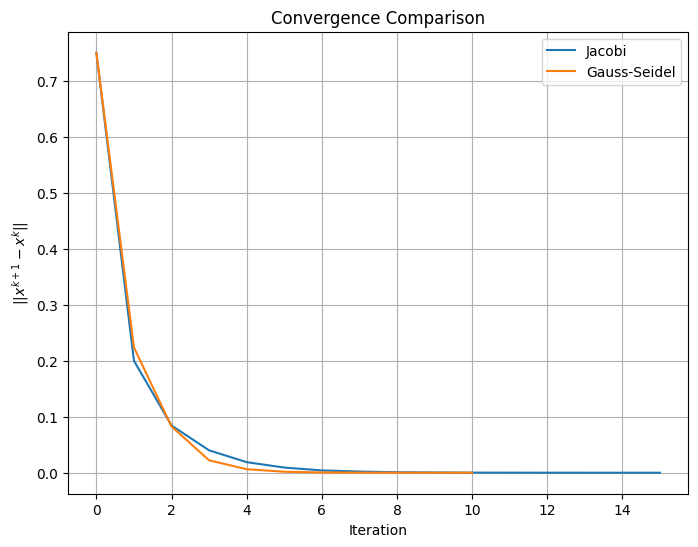

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.plot(hist_j, label="Jacobi")       # use   Jacobi error history list
plt.plot(hist_g, label="Gauss-Seidel") # use  Gauss-Seidel error history list

plt.xlabel("Iteration")
plt.ylabel(r"$||x^{k+1} - x^k||$")
plt.title("Convergence Comparison")

plt.legend()
plt.grid(True)
plt.show()



##  Observation (Write in Markdown cell)

Answer the following:

1. Which curve drops faster?
2. Does this agree with the spectral radius values you computed earlier?
3. Explain why a smaller spectral radius leads to faster reduction of error.


In [ ]:
# q1 gauss seidel drop faster
# yes,gauss seidel has smaller spectral radius
